[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/lanzlagman/intro-python-astro-PUP/blob/main/solutions/03_solving_odes_numpy_scipy.ipynb)

> **Solutions copy.** Every **YOUR TURN** cell below is already filled in. Work through `notebooks/` first; read this afterwards.

# Notebook 03: Solving ODEs with NumPy and SciPy

**Computational and Data-driven Astrophysics: A Practical Python Workshop**
PUP Physics Society · 15 August 2026

---

Notebook 02 got data by **downloading** it. This notebook gets data by **generating** it from the physics. Most research uses both, and comparing them is where discovery happens.

Many textbook orbit exercises are written against a companion program called `Orbit`. You are about to write your own in about fifteen lines, and yours will be more capable.

**UNIT CHOICE:** astronomical units, years, solar masses.

In this system G*M_sun = 4*pi^2 exactly, which keeps every number near 1 and makes numerical errors obvious instead of hidden in the exponent. This is the astronomer's version of "non-dimensionalising" an equation.

## Part 0: Setup

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

plt.rcParams["figure.figsize"] = (7, 5)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3

GM = 4 * np.pi**2      # AU^3 / yr^2, for a 1 solar-mass central body
print(f"GM = {GM:.4f}  AU^3 / yr^2")

GM = 39.4784  AU^3 / yr^2


---
## Part 1: Writing the physics as code

Newton's law of gravitation gives the acceleration of a small body about a much larger mass
$M$ at the origin:

$$ \ddot{\vec{r}} = -\frac{GM}{r^3}\vec{r} $$

That is **second-order**, and solvers want **first-order**. The standard trick: stop tracking
position alone and track position *and* velocity together as one four-component state vector.

$$ \vec{y} = (x,\ y,\ v_x,\ v_y), \qquad
   \dot{\vec{y}} = \left(v_x,\ v_y,\ -\frac{GM x}{r^3},\ -\frac{GM y}{r^3}\right) $$

Everything after this is bookkeeping. The physics is in the next four lines.

In [2]:
def two_body(t, y):
    """Right-hand side of the two-body problem.  y = [x, y, vx, vy]"""
    x, y_pos, vx, vy = y
    r = np.hypot(x, y_pos)
    ax = -GM * x / r**3
    ay = -GM * y_pos / r**3
    return [vx, vy, ax, ay]

def initial_state(a, e):
    """Start at perihelion.  The vis-viva equation gives the speed there.

        v^2 = GM (2/r - 1/a),   with  r_perihelion = a(1 - e)
    """
    r_p = a * (1 - e)
    v_p = np.sqrt(GM * (2 / r_p - 1 / a))
    return [r_p, 0.0, 0.0, v_p]

def orbital_energy(state, a=None):
    """Specific orbital energy.  This must equal -GM/(2a),
    constant for all time. Any drift is numerical error, not physics."""
    x, y, vx, vy = np.asarray(state)
    return 0.5 * (vx**2 + vy**2) - GM / np.hypot(x, y)

# Earth: a = 1 AU, e = 0.0167
y0 = initial_state(a=1.0, e=0.0167)
print("Earth initial state [x, y, vx, vy] =", np.round(y0, 4))
print(f"speed at perihelion = {y0[3]:.4f} AU/yr = {y0[3]*4.74:.2f} km/s")
print(f"energy (theory predicts {-GM/2:.4f}) = {orbital_energy(y0):.4f}")

Earth initial state [x, y, vx, vy] = [0.9833 0.     0.     6.389 ]
speed at perihelion = 6.3890 AU/yr = 30.28 km/s
energy (theory predicts -19.7392) = -19.7392


---
## Part 2: Doing it the hard way first: Euler's method

Before reaching for a library, write the simplest possible integrator by hand. It is ten
lines, and understanding *why it fails* is the entire justification for everything that
follows.

Euler's method takes the derivative at the current point and steps blindly forward:

$$ \vec{y}_{n+1} = \vec{y}_n + h\,\dot{\vec{y}}_n $$

In [3]:
def euler(f, y0, t_end, h):
    """Forward Euler. The simplest ODE integrator that exists."""
    n = int(t_end / h)
    t = np.linspace(0, t_end, n + 1)
    y = np.zeros((n + 1, len(y0)))
    y[0] = y0
    for i in range(n):
        y[i + 1] = y[i] + h * np.array(f(t[i], y[i]))
    return t, y


t_eu, y_eu = euler(two_body, y0, t_end=20.0, h=0.001)   # 20 years, ~1000 steps/orbit
print(f"{len(t_eu)} steps over 20 years")
print(f"start radius: {np.hypot(*y_eu[0][:2]):.4f} AU")
print(f"end   radius: {np.hypot(*y_eu[-1][:2]):.4f} AU")

20001 steps over 20 years
start radius: 0.9833 AU
end   radius: 1.8111 AU


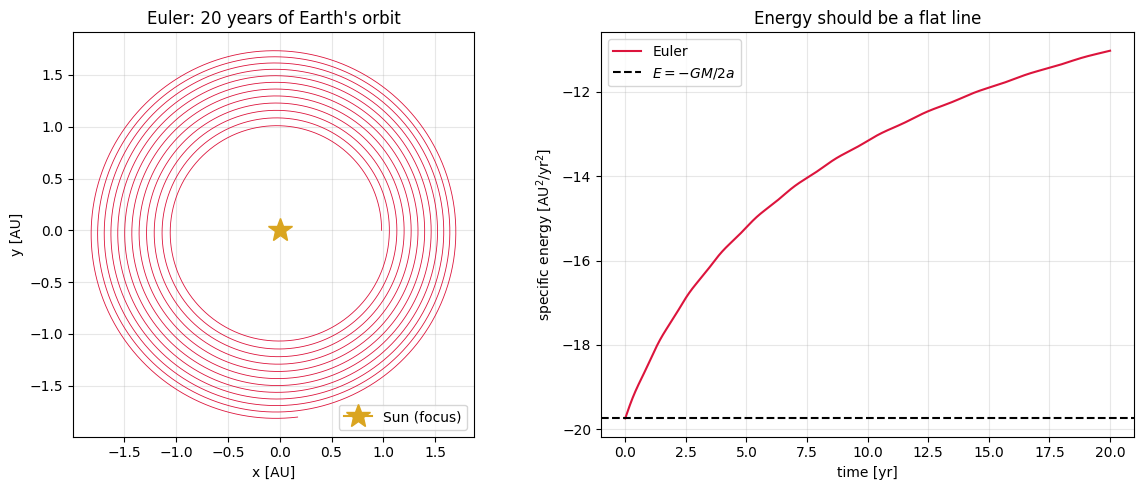

energy drift over 20 yr: +44.1%


In [4]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

ax1.plot(y_eu[:, 0], y_eu[:, 1], lw=0.6, color="crimson")
ax1.plot(0, 0, marker="*", ms=18, color="goldenrod", label="Sun (focus)")
ax1.set_aspect("equal")
ax1.set_xlabel("x [AU]"); ax1.set_ylabel("y [AU]")
ax1.set_title("Euler: 20 years of Earth's orbit")
ax1.legend()

E_eu = orbital_energy(y_eu.T)
ax2.plot(t_eu, E_eu, color="crimson", label="Euler")
ax2.axhline(-GM / 2, ls="--", color="k", label="$E = -GM/2a$")
ax2.set_xlabel("time [yr]"); ax2.set_ylabel("specific energy [AU$^2$/yr$^2$]")
ax2.set_title("Energy should be a flat line")
ax2.legend()

plt.tight_layout(); plt.show()

print(f"energy drift over 20 yr: {100*(E_eu[-1]-E_eu[0])/abs(E_eu[0]):+.1f}%")


> **Look at what happened.** Earth spiralled outward. The orbit did not close, and the total
> energy; a constant of the motion; climbed steadily.
>
> The physics is exact. What is wrong is that Euler's method assumes the derivative stays
> constant across each step. The error accumulates in one direction, so the planet gains
> energy it should not have.
>
> **A bad integrator does not throw an error. It hands you a beautiful, plausible, wrong
> answer.**

---
## Part 3: Doing it the easy way: `scipy.integrate.solve_ivp`

SciPy's `solve_ivp` implements adaptive Runge–Kutta methods: it estimates its own error at
each step and shrinks the step size where the physics is changing fast (near perihelion)
and grows it where nothing much is happening (near aphelion).

Same physics function. Same initial conditions. One line.

solver: The solver successfully reached the end of the integration interval.
internal steps taken: 22988 function evaluations


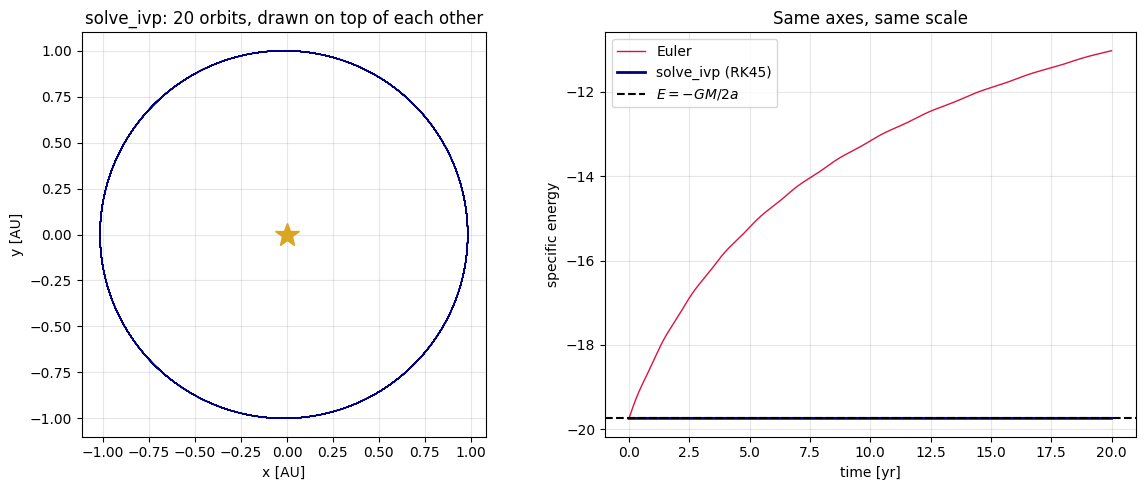

Euler     drift: +44.1388%
solve_ivp drift: +3.7690e-07%


In [5]:
sol = solve_ivp(
    two_body, [0, 20], y0,
    t_eval=np.linspace(0, 20, 4000),
    rtol=1e-10, atol=1e-12,       # ask for tight tolerances
)

print("solver:", sol.message)
print(f"internal steps taken: {sol.nfev} function evaluations")

E_sp = orbital_energy(sol.y)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
ax1.plot(sol.y[0], sol.y[1], lw=0.8, color="navy")
ax1.plot(0, 0, marker="*", ms=18, color="goldenrod")
ax1.set_aspect("equal"); ax1.set_xlabel("x [AU]"); ax1.set_ylabel("y [AU]")
ax1.set_title("solve_ivp: 20 orbits, drawn on top of each other")

ax2.plot(t_eu, E_eu, color="crimson", label="Euler", lw=1)
ax2.plot(sol.t, E_sp, color="navy", label="solve_ivp (RK45)", lw=2)
ax2.axhline(-GM / 2, ls="--", color="k", label="$E = -GM/2a$")
ax2.set_xlabel("time [yr]"); ax2.set_ylabel("specific energy")
ax2.legend(); ax2.set_title("Same axes, same scale")

plt.tight_layout(); plt.show()

print(f"Euler     drift: {100*(E_eu[-1]-E_eu[0])/abs(E_eu[0]):+.4f}%")
print(f"solve_ivp drift: {100*(E_sp[-1]-E_sp[0])/abs(E_sp[0]):+.4e}%")

> Twenty orbits later the second orbit is still exactly on top of the first, and the energy is
> conserved to roughly one part in $10^{10}$.
>
> **If you have solved ODEs before:** the interesting question is no longer syntax, it is
> *error control*. Try `method="DOP853"`, or loosen `rtol` to `1e-4` and watch where the
> accuracy goes.

---
## Part 4: Three eccentricities, one year

Plot the orbits of three hypothetical objects around the Sun, all with semimajor axis
$a = 1$ AU and eccentricities **0.0, 0.4 and 0.8**, on common axes, marking the principal
focus at the origin.

You now have your own `Orbit`. Note what Kepler's third law demands: all three have
$a = 1$ AU, so all three must have the **same period of exactly one year**, however different
the shapes look.

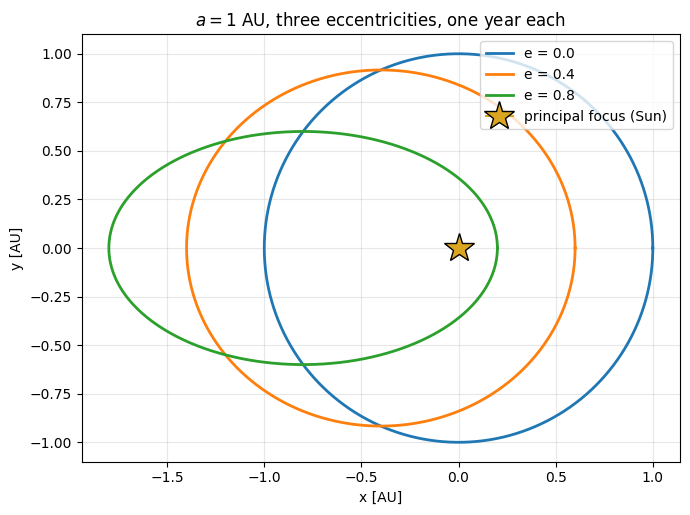

All three closed after exactly 1.0 yr of integration.
Same semimajor axis -> same period. That is Kepler III.


In [6]:
fig, ax = plt.subplots(figsize=(7, 7))
colors = {0.0: "tab:blue", 0.4: "tab:orange", 0.8: "tab:green"}

for e, color in colors.items():
    s = solve_ivp(two_body, [0, 1.0], initial_state(a=1.0, e=e),
                  t_eval=np.linspace(0, 1.0, 2000), rtol=1e-10, atol=1e-12)
    ax.plot(s.y[0], s.y[1], color=color, lw=2, label=f"e = {e}")

# The principal focus, as the problem explicitly requires
ax.plot(0, 0, marker="*", ms=22, color="goldenrod",
        markeredgecolor="k", zorder=5, label="principal focus (Sun)")

ax.set_aspect("equal")
ax.set_xlabel("x [AU]"); ax.set_ylabel("y [AU]")
ax.set_title("$a = 1$ AU, three eccentricities, one year each")
ax.legend(loc="upper right")
plt.tight_layout(); plt.show()

print("All three closed after exactly 1.0 yr of integration.")
print("Same semimajor axis -> same period. That is Kepler III.")

### ✏️ YOUR TURN

Comet Halley has $e \approx 0.967$. Add it to the picture.

Use `initial_state(a=17.8, e=0.967)`: Halley's real semimajor axis is 17.8 AU; and integrate for its full period. **Kepler III says $P = a^{3/2}$ years when $a$ is in AU.** Work out that number before you run the cell.

predicted period: 75.1 yr   (the observed value is 75-76 yr)


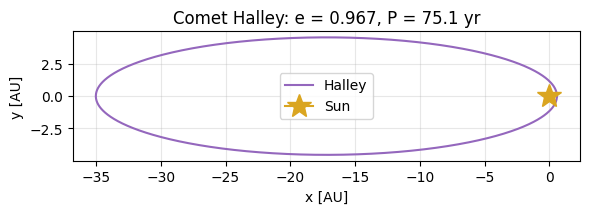

perihelion 0.59 AU (inside Earth's orbit), aphelion 35.0 AU (beyond Neptune)


In [7]:
a_halley, e_halley = 17.8, 0.967

# YOUR TURN: Kepler III in solar units.  P = a**1.5 years.
P_halley = a_halley ** 1.5

# ---- check ----
if P_halley is None:
    print("Fill in the line above, then re-run.")
else:
    print(f"predicted period: {P_halley:.1f} yr   (the observed value is 75-76 yr)")
    s = solve_ivp(two_body, [0, P_halley], initial_state(a_halley, e_halley),
                  t_eval=np.linspace(0, P_halley, 4000), rtol=1e-10, atol=1e-12)
    fig, ax = plt.subplots(figsize=(6, 5))
    ax.plot(s.y[0], s.y[1], color="tab:purple", lw=1.5, label="Halley")
    ax.plot(0, 0, marker="*", ms=18, color="goldenrod", label="Sun")
    ax.set_aspect("equal"); ax.set_xlabel("x [AU]"); ax.set_ylabel("y [AU]")
    ax.set_title(f"Comet Halley: e = {e_halley}, P = {P_halley:.1f} yr")
    ax.legend(); plt.tight_layout(); plt.show()
    print(f"perihelion {a_halley*(1-e_halley):.2f} AU (inside Earth's orbit), "
          f"aphelion {a_halley*(1+e_halley):.1f} AU (beyond Neptune)")

---
## Part 5: Checking Kepler's second law

$$ \frac{dA}{dt} = \frac{1}{2}r^2\frac{d\theta}{dt} = \frac{L}{2\mu} = \text{constant} $$

A line from the Sun to the planet sweeps out **equal areas in equal times**: angular momentum conservation wearing a geometric disguise.

We never told the solver about this. If it comes out of the integration anyway, the
integration is trustworthy.

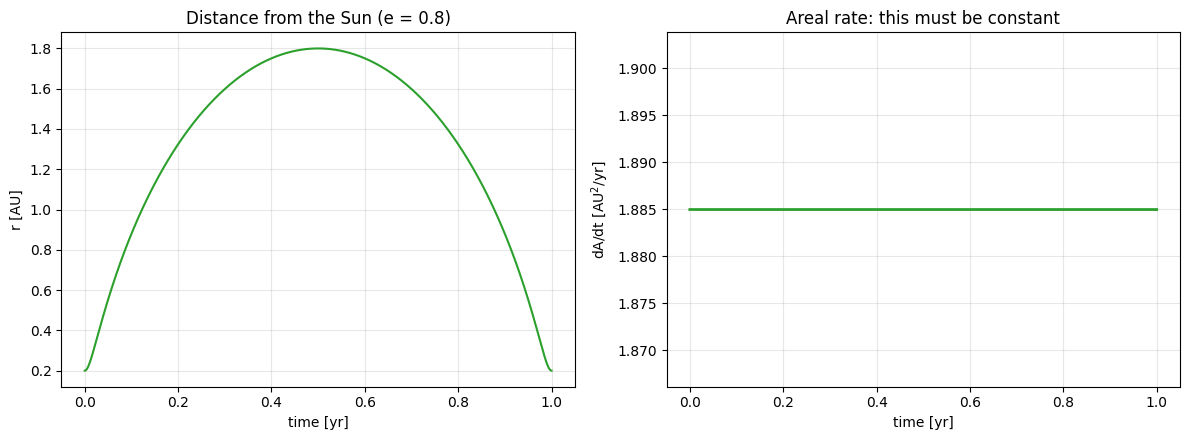

dA/dt varies by 3.74e-09% over the orbit
The planet's distance changes by a factor of 9. The areal rate does not move.


In [8]:
s = solve_ivp(two_body, [0, 1.0], initial_state(a=1.0, e=0.8),
              t_eval=np.linspace(0, 1.0, 2000), rtol=1e-11, atol=1e-13)
x, y, vx, vy = s.y

# Swept area rate for a plane orbit is |r x v| / 2
dA_dt = 0.5 * np.abs(x * vy - y * vx)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4.5))
ax1.plot(s.t, np.hypot(x, y), color="tab:green")
ax1.set_xlabel("time [yr]"); ax1.set_ylabel("r [AU]")
ax1.set_title("Distance from the Sun (e = 0.8)")

ax2.plot(s.t, dA_dt, color="tab:green", lw=2)
ax2.set_xlabel("time [yr]"); ax2.set_ylabel("dA/dt [AU$^2$/yr]")
ax2.set_title("Areal rate: this must be constant")
ax2.set_ylim(dA_dt.mean() * 0.99, dA_dt.mean() * 1.01)
plt.tight_layout(); plt.show()

print(f"dA/dt varies by {100*(dA_dt.max()-dA_dt.min())/dA_dt.mean():.2e}% over the orbit")
print("The planet's distance changes by a factor of 9. The areal rate does not move.")

---
## Part 6: Weighing Jupiter

Verify Kepler's third law on the four moons Galileo discovered in 1610, then use it to weigh
the planet.

$$ P^2 = \frac{4\pi^2}{G(m_1+m_2)}a^3 $$

Take logs: $\log P = \frac{3}{2}\log a + \frac{1}{2}\log\!\left(\frac{4\pi^2}{GM}\right)$.
A straight line. The **slope tests the law**; the **intercept weighs the planet**.

This is the moment the notebook stops being a plotting exercise. Galileo's 1610 observations,
four numbers, and `np.polyfit` are enough to determine the mass of a planet you will never
visit.

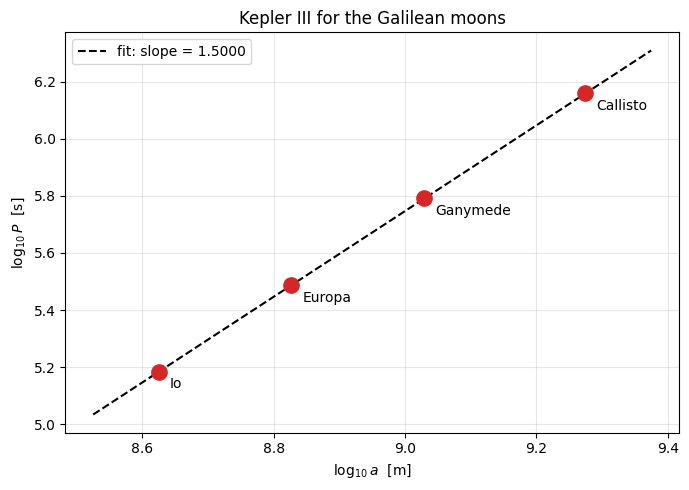

(b) measured slope = 1.500000      Kepler III predicts 1.5


In [9]:
# Galilean moons: semimajor axis [m] and orbital period [days]
moons = {
    "Io":       (421_700e3,   1.769138),
    "Europa":   (671_034e3,   3.551181),
    "Ganymede": (1_070_412e3, 7.154553),
    "Callisto": (1_882_709e3, 16.689017),
}
names = list(moons)
a_m = np.array([moons[n][0] for n in names])              # metres
P_s = np.array([moons[n][1] for n in names]) * 86400.0    # seconds

# (a) and (b): the log-log fit
slope, intercept = np.polyfit(np.log10(a_m), np.log10(P_s), 1)

fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(np.log10(a_m), np.log10(P_s), "o", ms=11, color="tab:red", zorder=3)
xs = np.linspace(np.log10(a_m).min() - 0.1, np.log10(a_m).max() + 0.1, 50)
ax.plot(xs, slope * xs + intercept, "--", color="k",
        label=f"fit: slope = {slope:.4f}")
for n, ax_, py in zip(names, np.log10(a_m), np.log10(P_s)):
    ax.annotate(n, (ax_, py), textcoords="offset points", xytext=(8, -12))
ax.set_xlabel(r"$\log_{10} a$  [m]"); ax.set_ylabel(r"$\log_{10} P$  [s]")
ax.set_title("Kepler III for the Galilean moons")
ax.legend(); plt.tight_layout(); plt.show()

print(f"(b) measured slope = {slope:.6f}      Kepler III predicts 1.5")

In [10]:
# (c) Jupiter's mass from the intercept
G = 6.67430e-11                       # m^3 kg^-1 s^-2
M_jupiter = 4 * np.pi**2 / (G * (10**intercept)**2)

print(f"(c) Jupiter's mass from the intercept: {M_jupiter:.4e} kg")
print(f"    accepted value                   : 1.898e+27 kg")
print(f"    error                            : {100*abs(M_jupiter-1.898e27)/1.898e27:.2f}%")
print()
print("Four numbers Galileo could have measured in 1610, one straight-line fit,")
print("and the mass of a planet 600 million km away. Kepler III is the most")
print("direct way we have of weighing celestial objects.")

(c) Jupiter's mass from the intercept: 1.8985e+27 kg
    accepted value                   : 1.898e+27 kg
    error                            : 0.03%

Four numbers Galileo could have measured in 1610, one straight-line fit,
and the mass of a planet 600 million km away. Kepler III is the most
direct way we have of weighing celestial objects.


---
## What you built, and where it goes

| You wrote | Next used in |
|---|---|
| A state-vector formulation of Newtonian gravity | any dynamical problem you ever meet |
| Hand-rolled Euler, and why it fails | the reason to trust libraries, and to test them |
| `solve_ivp` with error control | the exoplanet and gravitational-wave papers in Part 2 |
| `np.polyfit` on log-log axes | the open-clusters paper in Part 2 |
| Conservation laws as correctness tests | every simulation you will ever write |

The same `solve_ivp` call, aimed at a different equation, is the whole of stellar structure, the exoplanet radial-velocity signal, and the inspiral that produces a gravitational-wave chirp. A decaying two-body orbit *is* a chirp: the separation shrinks, so the frequency rises.

**Notebook 04** asks a harder question than "how do I plot this?": it asks **how do I make a figure someone can defend?**

---
### Sources

Orbital mechanics follows Carroll & Ostlie, *An Introduction to Modern Astrophysics*, 2nd ed.: §2.1 (Elliptical Orbits) and §2.3 (Kepler's Laws Derived). Parts 4 and 6 are adapted from that chapter's problem set.

### If you want to go deeper
- Zingale, *Tutorial on Computational Astrophysics*: *Basic Methods for ODEs*, *Higher-order Accurate ODE Integration*, *Root Finding* · <https://zingale.github.io/comp_astro_tutorial/>
- Pasha & Agostino, *Building an RK4 Orbit Integrator* · <https://prappleizer.github.io/>
- SciPy docs: `solve_ivp` method comparison (RK45, DOP853, Radau, LSODA)